# Transformer Model with the RadioML 2018A Dataset

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
from src.dataset import *
from src.utils import *
from src.config import setup_environment

In [3]:
GLOBAL_SEED = 2026
setup_environment(seed=GLOBAL_SEED)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
path = "/home/wicom/Descargas/" # adjust yours
file = "GOLD_XYZ_OSC.0001_1024.hdf5"
classes = RadioMLConfig.CLASSES
fs = RadioMLConfig.FS
X, Y, Z = load_dataset(path, file)

[INFO] Loading /home/wicom/Descargas/GOLD_XYZ_OSC.0001_1024.hdf5 ...
[INFO] Loaded Dataset | X:(2555904, 1024, 2) Y:(2555904, 24) Z:(2555904, 1) | dtype X:float32


In [5]:
X = normalize_rms(X)

In [6]:
# split: train/val/test: 0.7/0.15/0.15
X_train, Y_train, Z_train, X_val, Y_val, Z_val, X_test, Y_test, Z_test = split_dataset(X, Y, Z, 
                                                                                       val_size=0.15,
                                                                                       test_size=0.15)

In [7]:
print("[INFO] Dataset split done!")
print("Train:", X_train.shape, Y_train.shape, Z_train.shape)
print("Val:  ", X_val.shape,   Y_val.shape,   Z_val.shape)
print("Test: ", X_test.shape,  Y_test.shape,  Z_test.shape)

[INFO] Dataset split done!
Train: (1789132, 1024, 2) (1789132, 24) (1789132, 1)
Val:   (383386, 1024, 2) (383386, 24) (383386, 1)
Test:  (383386, 1024, 2) (383386, 24) (383386, 1)


In [ ]:
# use the tf.DATA API
BATCH_SIZE = 256
train_ds = build_tf_dataset(X_train, Y_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = build_tf_dataset(X_val,   Y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = build_tf_dataset(X_test,  Y_test,  batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] tf.data ok!")

In [8]:
# using PyDataset
BATCH_SIZE = 256
train_ds = PyDataset(X_train, Y_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = PyDataset(X_val,   Y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = PyDataset(X_test,  Y_test,  batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] PyDataset ok!")

[INFO] PyDataset ok!


In [9]:
from src.models.transformers import TransformerBlock, get_positional_encoding, build_transformer_model
from src.evaluate import PlotLosses

In [10]:
plot_losses = PlotLosses()

In [11]:
%load_ext autoreload
%autoreload 2

In [ ]:
from src.train import lr_search
parameters_dict = {
    "total_length": 1024,
    "patch_size": 16,
    "d_model": 128,
    "num_heads": 8,
    "ff_dim": 256,
    "num_layers": 2,
    "num_classes": 24,
    "name": "transformers_radioml2018"
}
lr_candidates = [1e-4, 3e-4, 1e-3, 3e-3]
best_lr = lr_search(lr_candidates, train_ds, val_ds, build_transformer_model, parameters_dict, 
                    epochs_per_trial=3, seed=GLOBAL_SEED)
# in this case: best_lr = 0.001

In [15]:
from src.train import compile_model_with_lr
model = build_transformer_model(parameters_dict)
model = compile_model_with_lr(model, best_lr) 
model.summary()

Model: "transformer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64, 128)        │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,048 (1.10 MB)

 Trainable params: 289,048 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

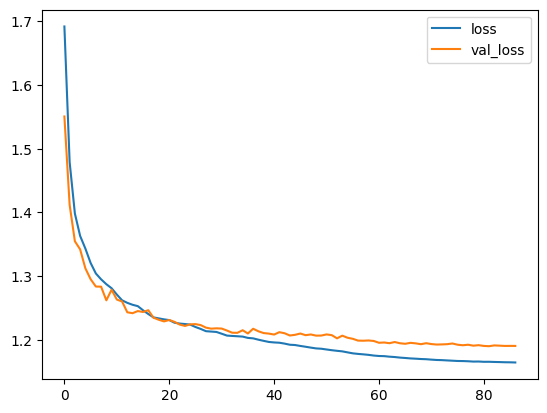

6989/6989 - 30s - 4ms/step - accuracy: 0.5988 - loss: 1.1645 - val_accuracy: 0.5926 - val_loss: 1.1904 - learning_rate: 1.0775e-05


In [18]:
from src.train import train_model
EPOCHS = 100
history, training_time = train_model(model=model, 
                                     train_ds=train_ds, 
                                     val_ds=val_ds,
                                     epochs=EPOCHS,
                                     plot_callback=plot_losses)

In [19]:
import pandas as pd
history_dict = pd.DataFrame(history.history)
display(history_dict)
history_dict.to_csv("./training_history_Transformers_RadioML2018A.csv", index=False)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.391223,1.691966,0.432473,1.550665,0.001000
1,0.461519,1.479047,0.491082,1.411953,0.001000
2,0.500382,1.398287,0.518587,1.354767,0.001000
3,0.515665,1.363180,0.525817,1.342067,0.001000
4,0.523985,1.343323,0.535959,1.312308,0.001000
...,...,...,...,...,...
82,0.598368,1.165265,0.592257,1.191240,0.000016
83,0.598616,1.165077,0.592502,1.190850,0.000015
84,0.598594,1.164816,0.592278,1.190429,0.000013
85,0.598596,1.164708,0.592385,1.190505,0.000012


In [ ]:
print("Save Modelo...", flush=True)
model.save("./Transformers1024_RadioML2018A.keras")

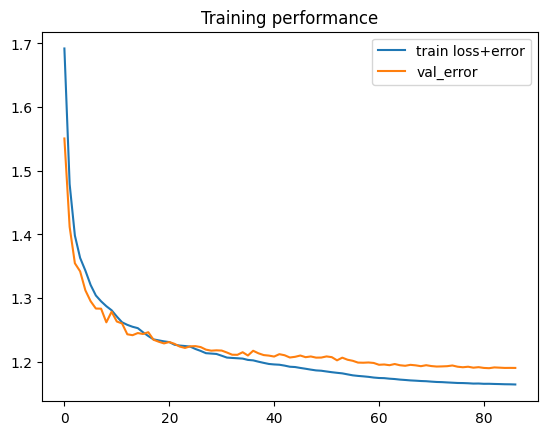

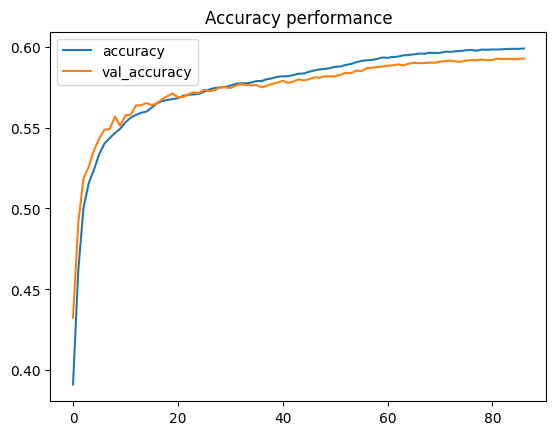

In [21]:
from src.evaluate import plot_loss, plot_accuracy

plot_loss(history)
plot_accuracy(history)

In [17]:
### TEST

In [15]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.layers.layer")

1498/1498 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5918 - loss: 1.1895
Test loss: 1.18952476978302
Test accuracy: 0.5918160676956177
457/457 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


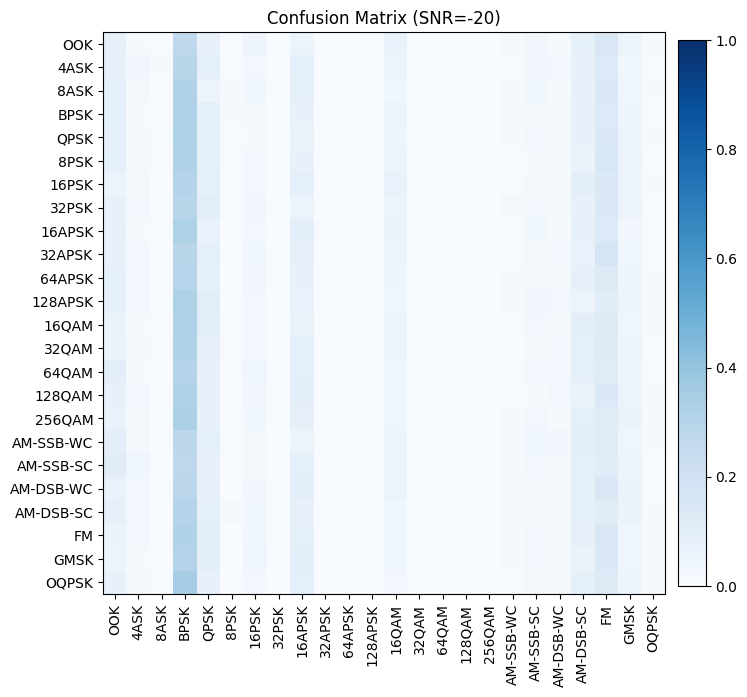

Overall Accuracy -20:  0.04465873341540145
459/459 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


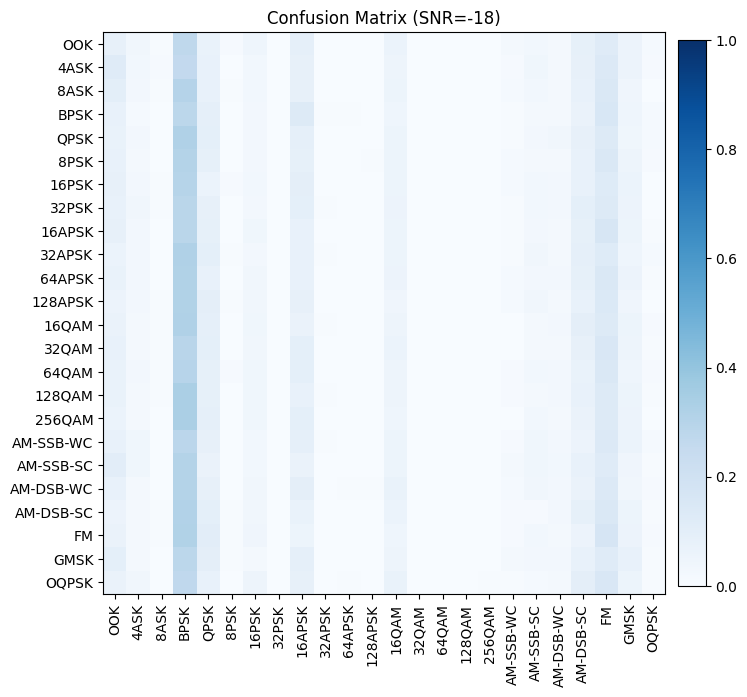

Overall Accuracy -18:  0.04233417410866453
457/457 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


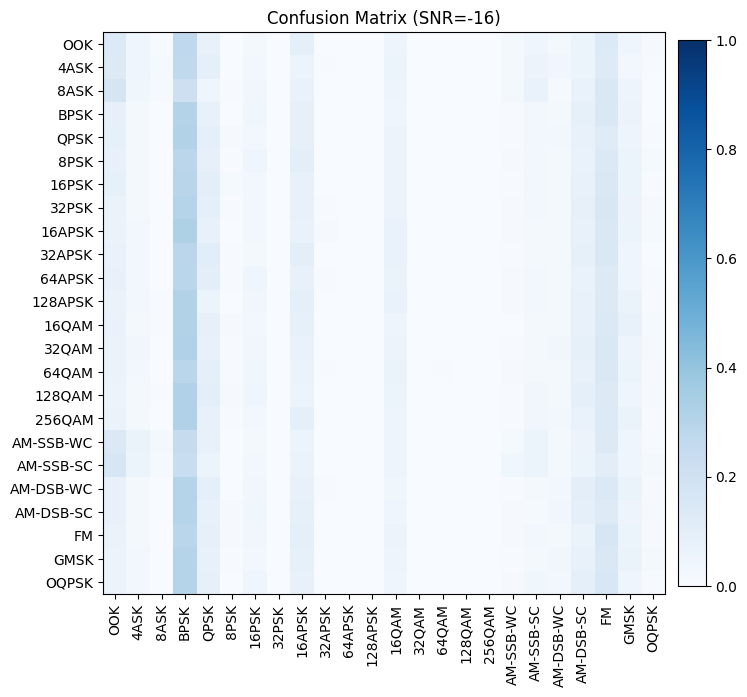

Overall Accuracy -16:  0.048518442482720865
463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


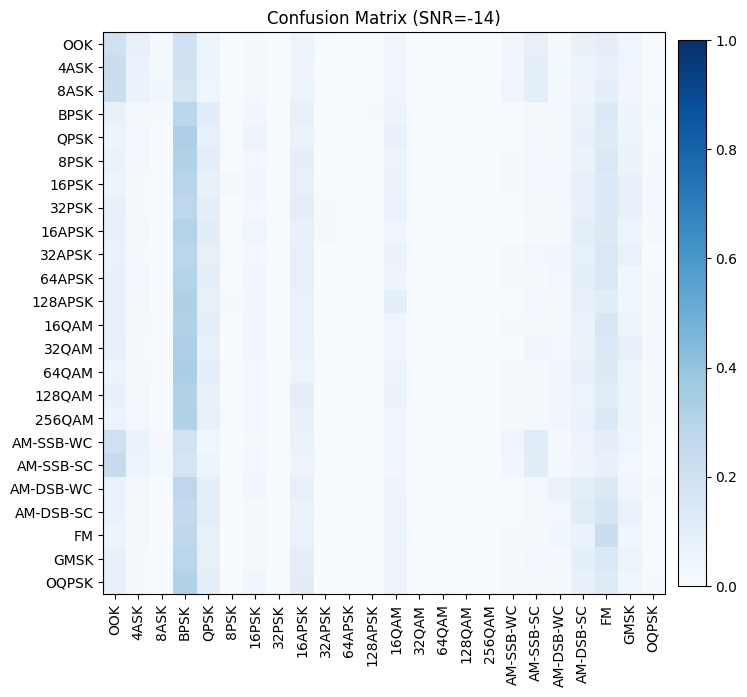

Overall Accuracy -14:  0.06056918812952072
457/457 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


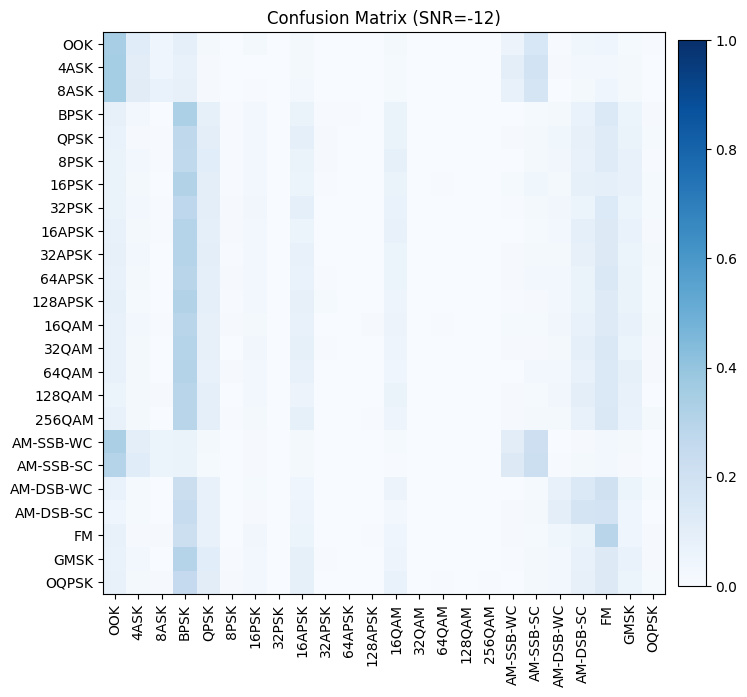

Overall Accuracy -12:  0.08462275777077913
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


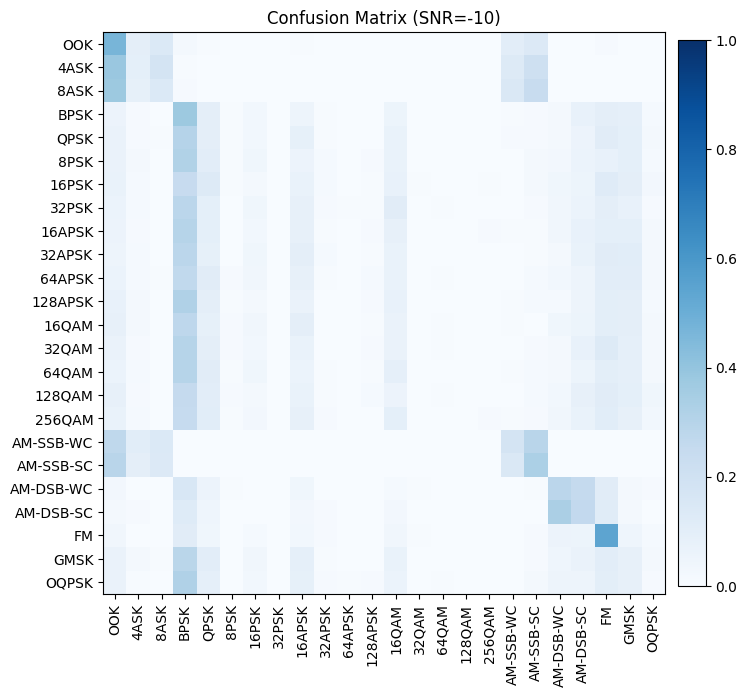

Overall Accuracy -10:  0.1285832414553473
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


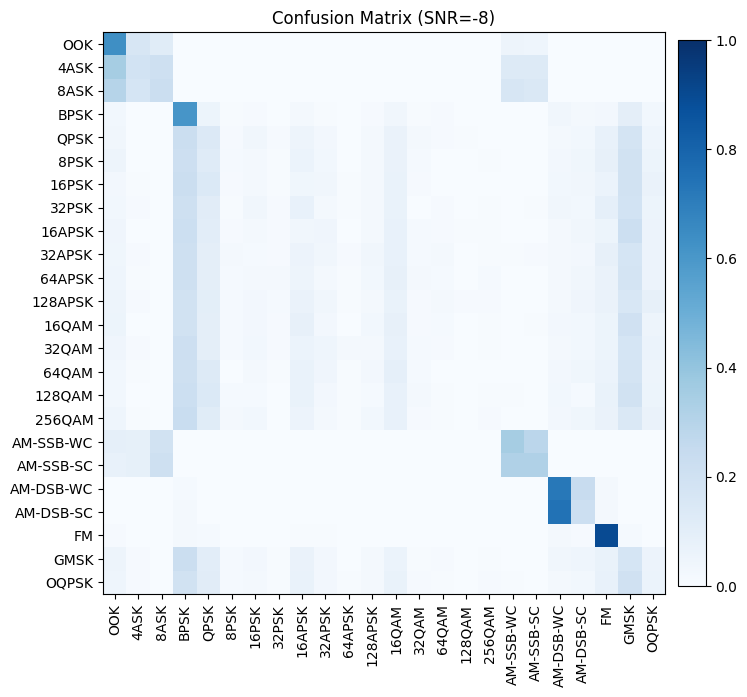

Overall Accuracy -8:  0.19979825151311364
463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


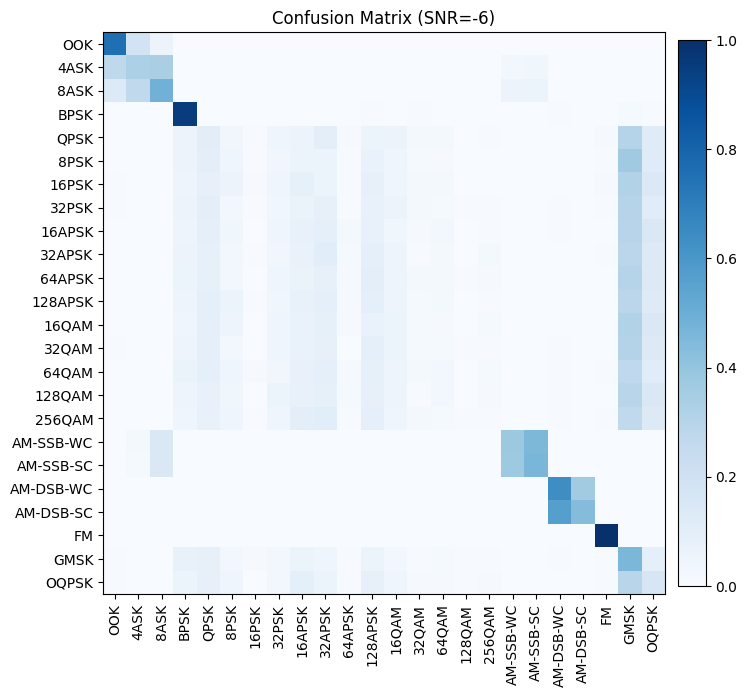

Overall Accuracy -6:  0.2767609914229756
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


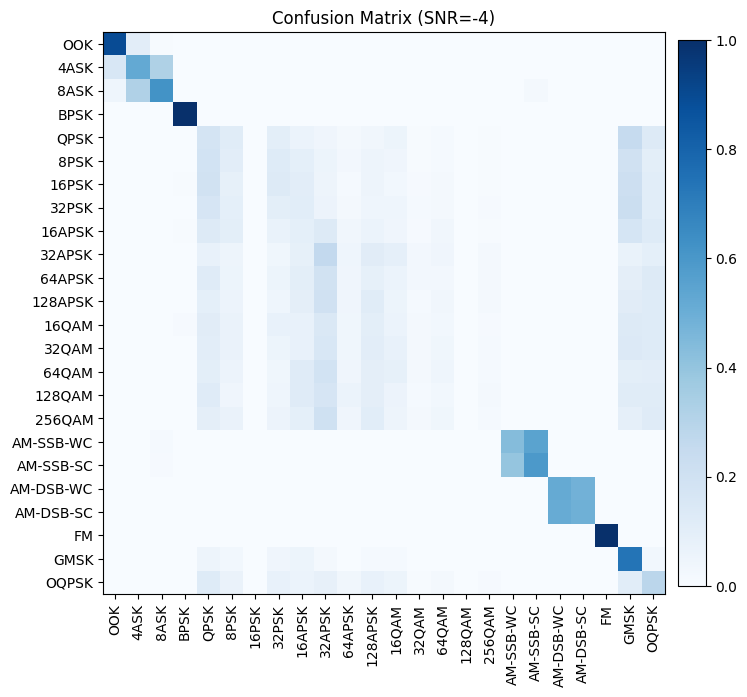

Overall Accuracy -4:  0.3405010718113612
463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


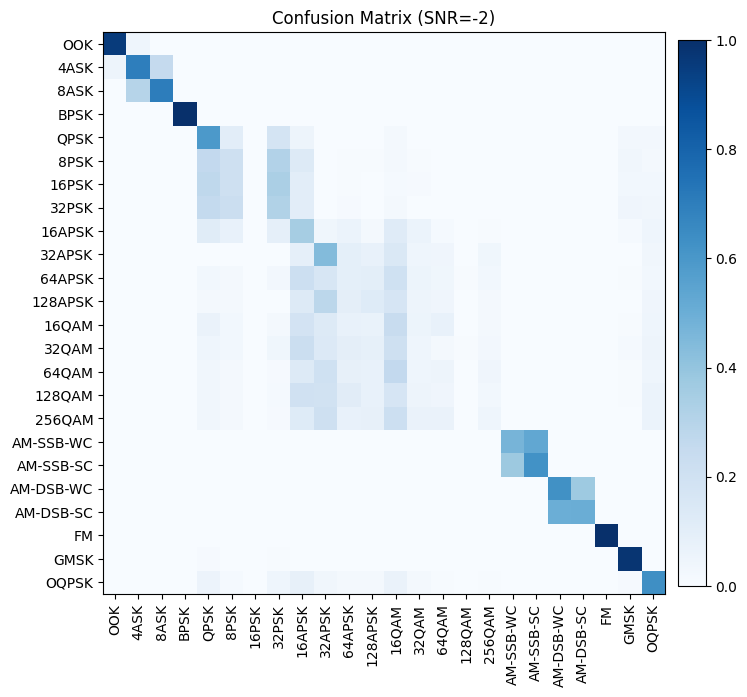

Overall Accuracy -2:  0.44439192383010334
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


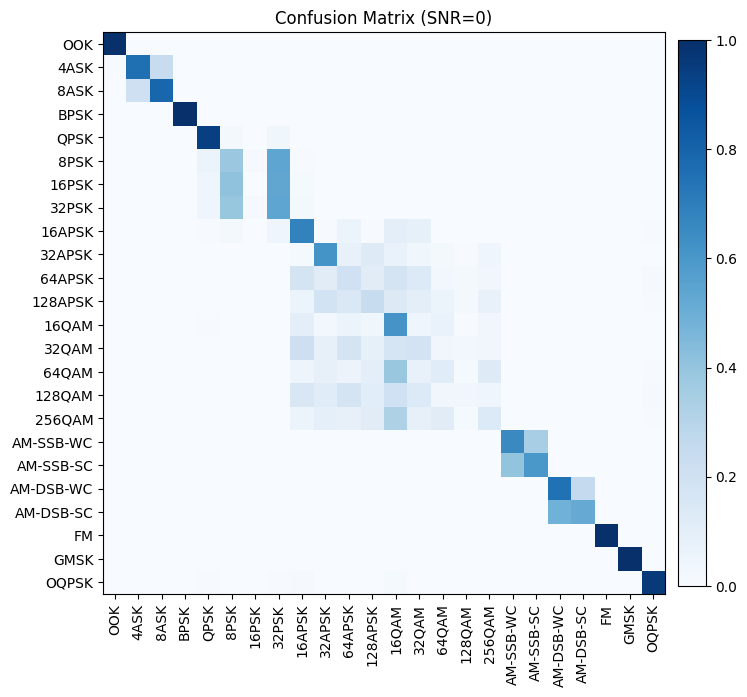

Overall Accuracy 0:  0.5679859989229941
461/461 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


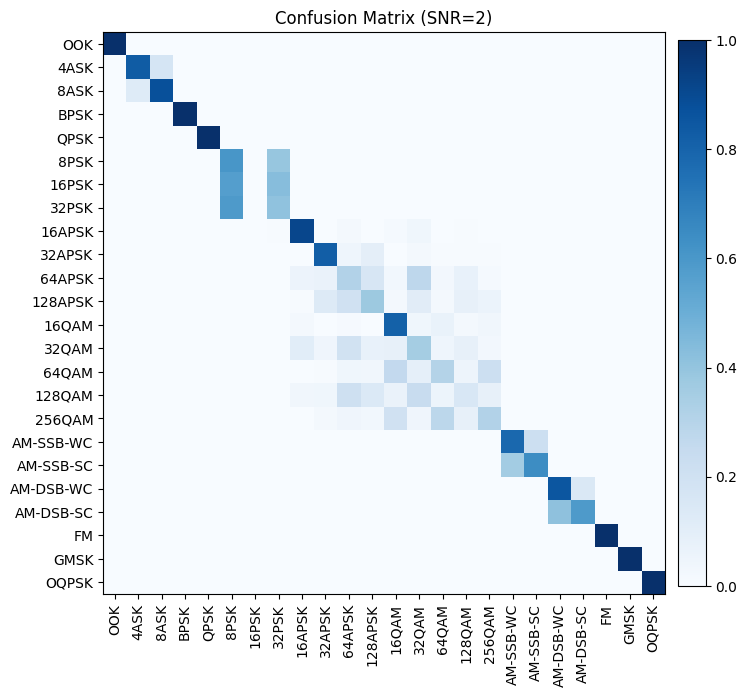

Overall Accuracy 2:  0.6623015334509431
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


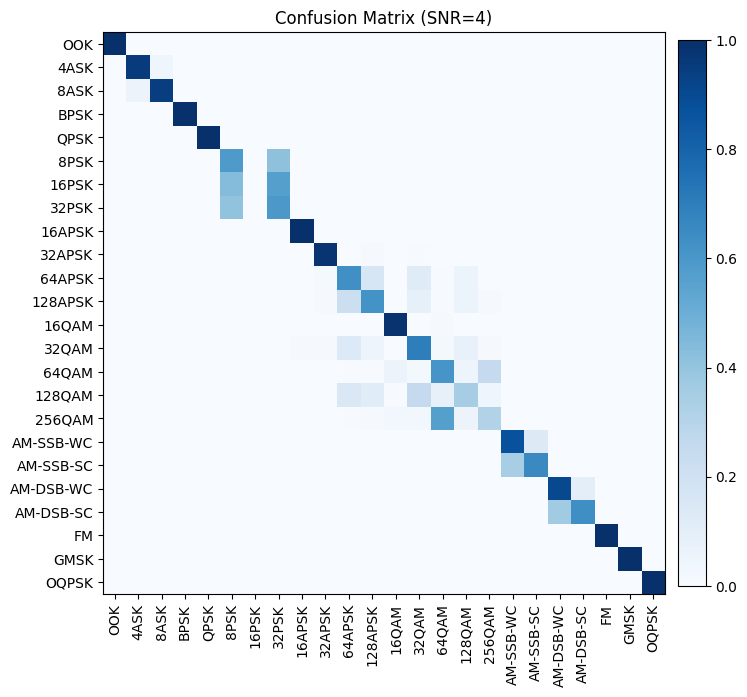

Overall Accuracy 4:  0.7639059723930572
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


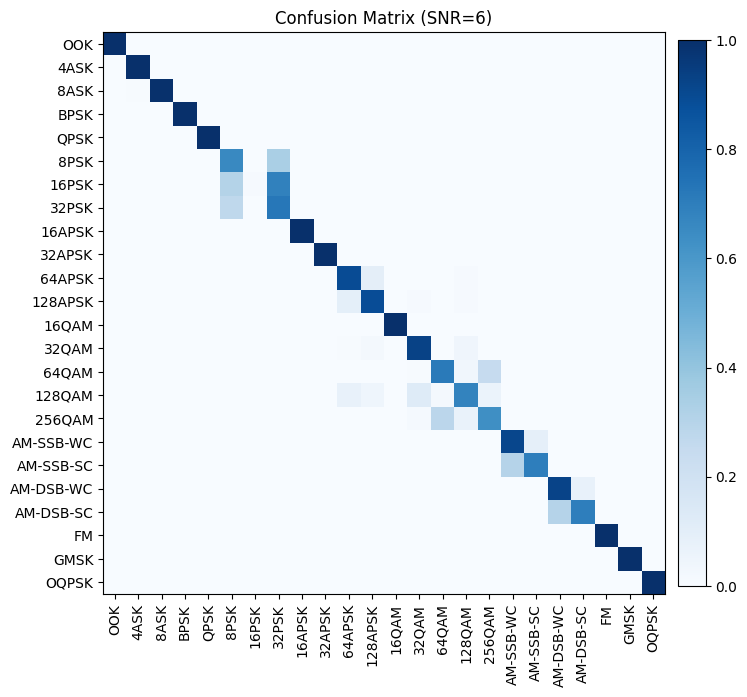

Overall Accuracy 6:  0.8500503862949278
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


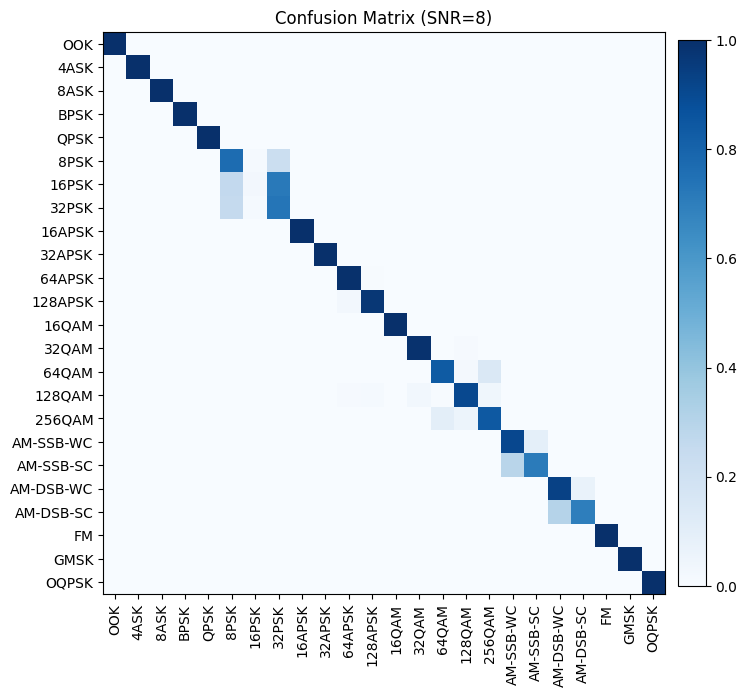

Overall Accuracy 8:  0.8888129102844639
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


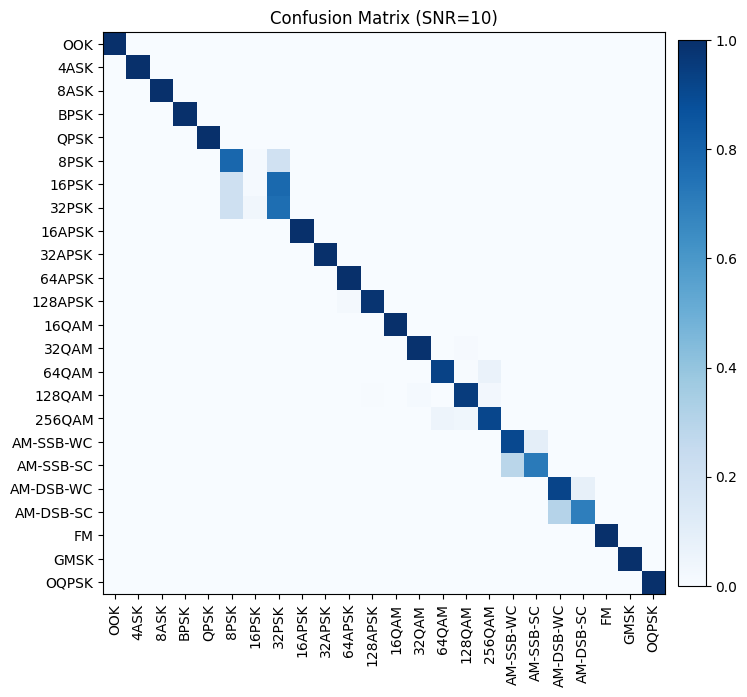

Overall Accuracy 10:  0.898201583680043
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


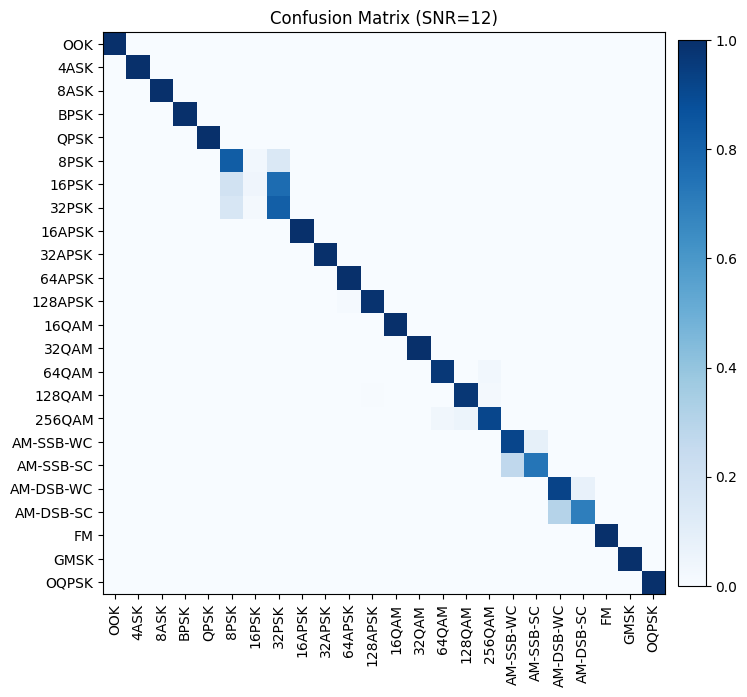

Overall Accuracy 12:  0.9076755727785709
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


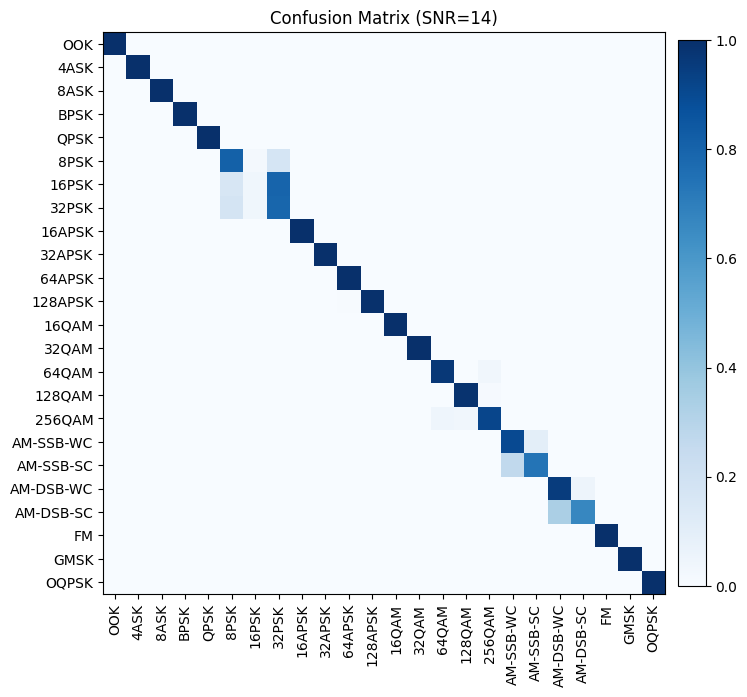

Overall Accuracy 14:  0.9063466451526153
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


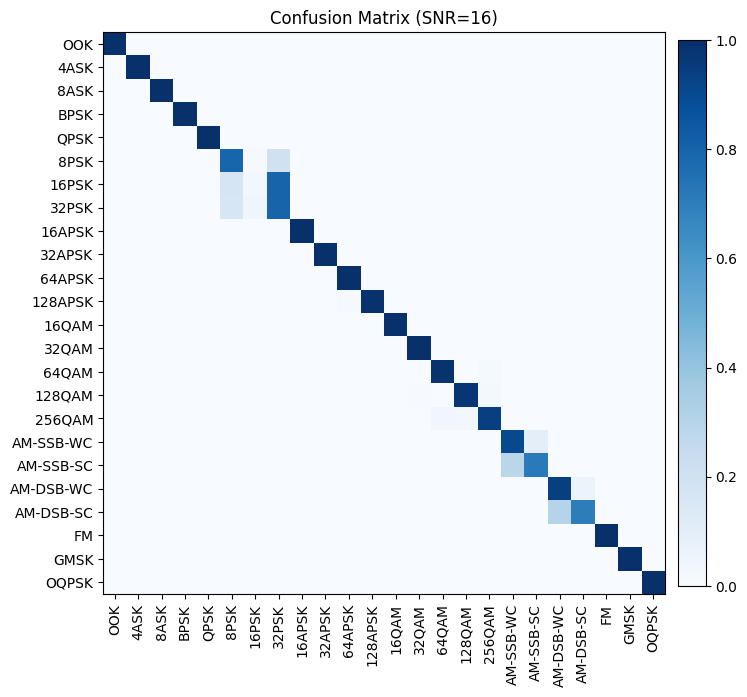

Overall Accuracy 16:  0.9068197164078325
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


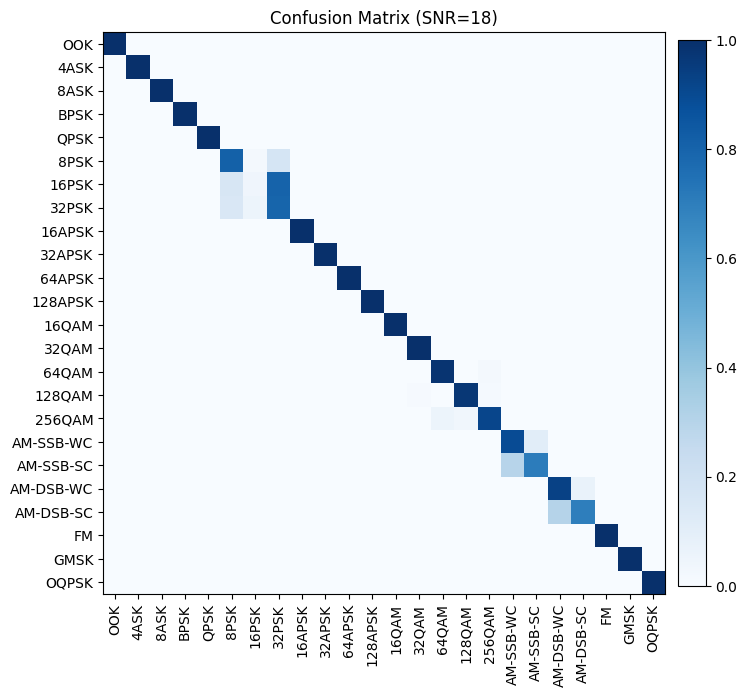

Overall Accuracy 18:  0.9052905701754386
459/459 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


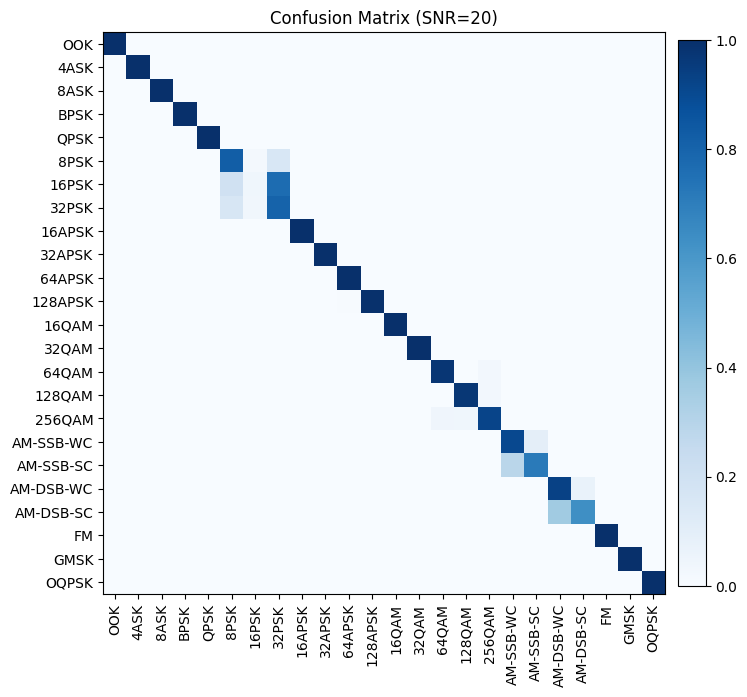

Overall Accuracy 20:  0.9031884452922742
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


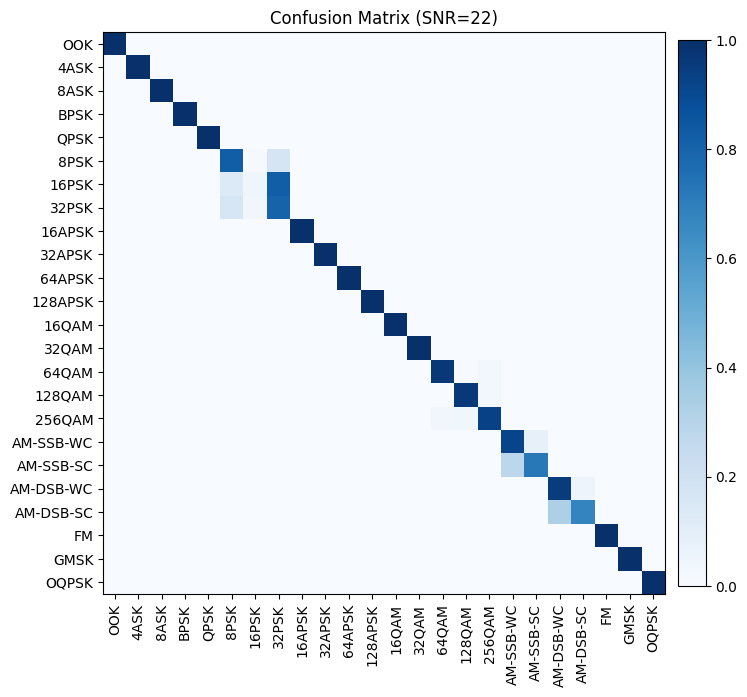

Overall Accuracy 22:  0.908266738298301
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


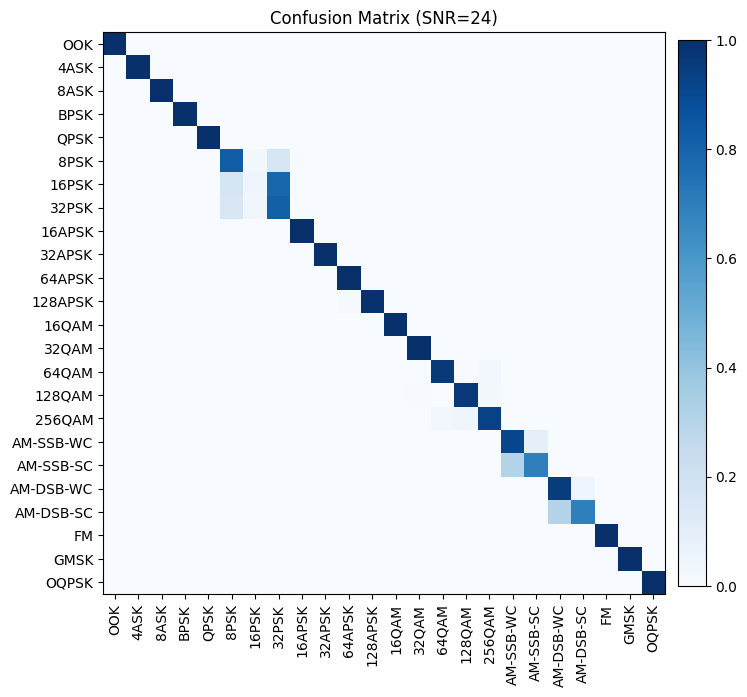

Overall Accuracy 24:  0.9077344284736482
462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


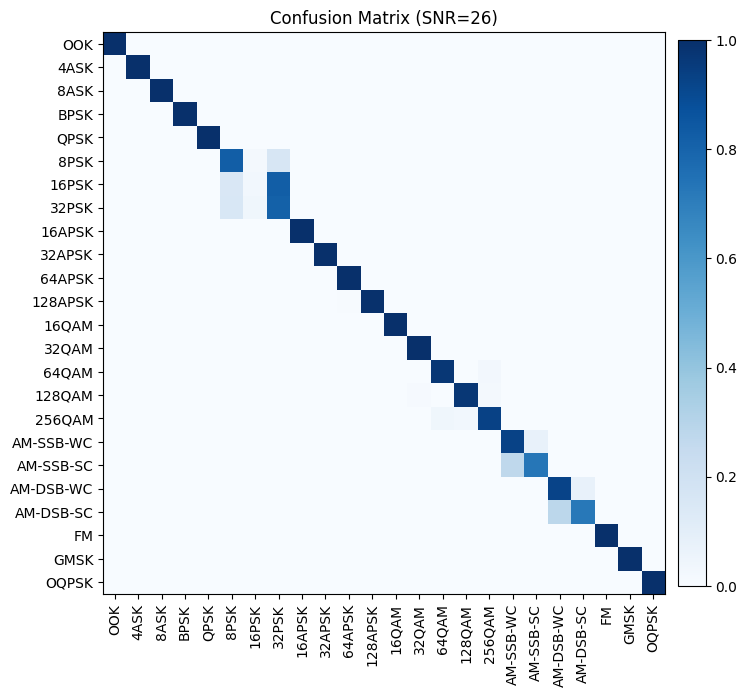

Overall Accuracy 26:  0.9082717973037057
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


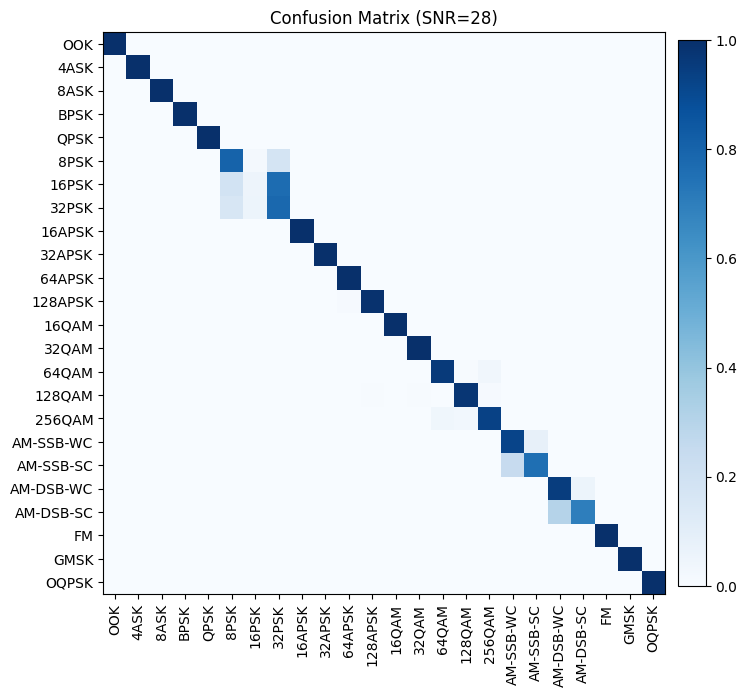

Overall Accuracy 28:  0.9068441064638784
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


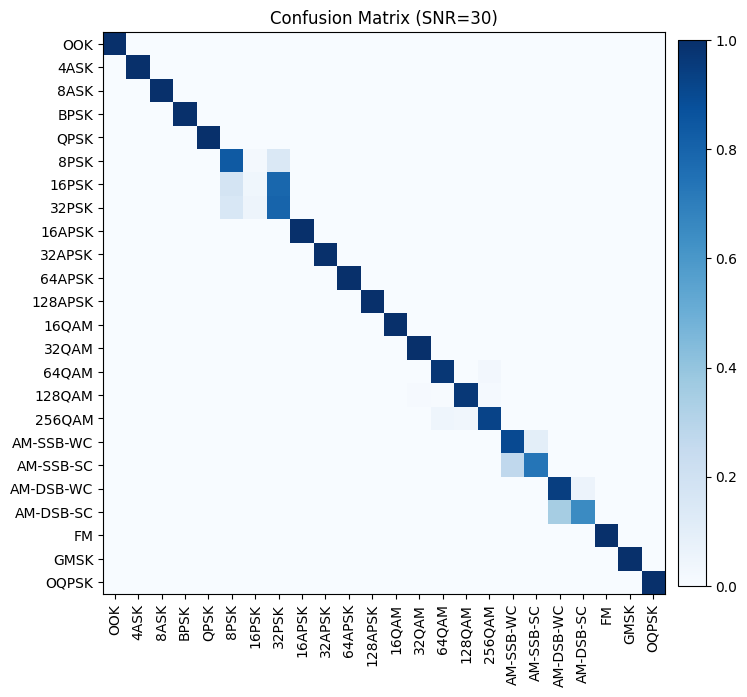

Overall Accuracy 30:  0.9072990245543222


In [16]:
from src.evaluate import evaluate_model_by_snr
path = './Transformers1024_RadioML2018A.keras'
results = evaluate_model_by_snr(model_path=path,
                                custom_objects={"TransformerBlock":TransformerBlock},
                                class_labels=classes,
                                snr_values=RadioMLConfig.SNR_RANGE,
                                data_gen=test_ds,
                                X_test=X_test,
                                Y_test=Y_test,
                                snr_test=Z_test)

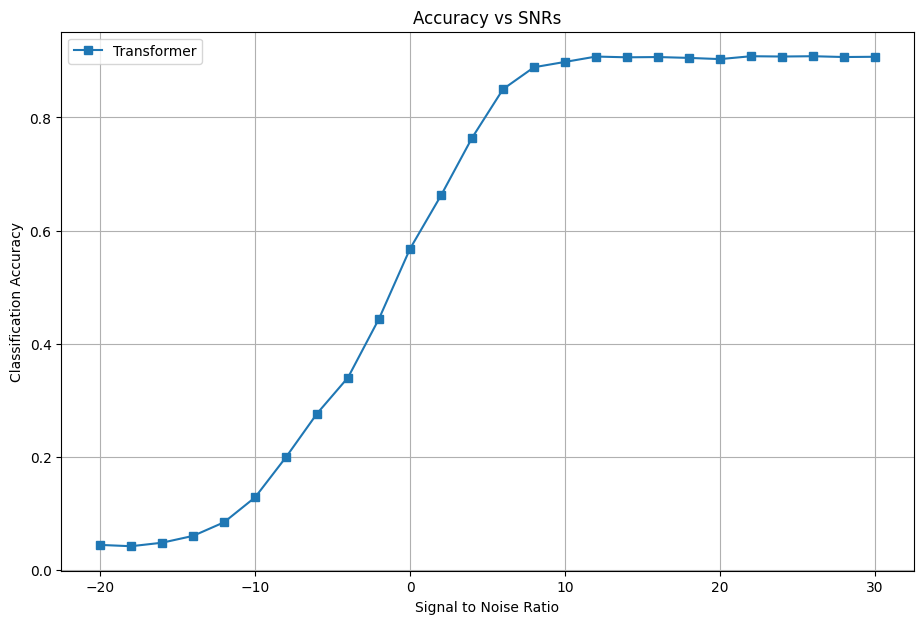

In [18]:
from src.evaluate import plot_accuracy_vs_snr
plot_accuracy_vs_snr(snr_values=RadioMLConfig.SNR_RANGE, 
                     accuracy_values=results,
                     label='Transformer')